#**Needed Setup**

###**libraries import and dataset load**

In [5]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


adult = fetch_openml(
    'adult',
    version=2,
    as_frame=True
)

df = adult.frame


###**Dataset overview**

In [6]:
df['class'].value_counts()

,count
class,
<=50K,37155
>50K,11687


###**Target convert to binary**

In [7]:
df['income'] = (df['class'] == '>50K').astype(int)

In [8]:
positive_rate = df['income'].mean()

print(f"People earning >50K: {positive_rate:.2%}")

People earning >50K: 23.93%


In [9]:
df['income'].value_counts()

,count
income,
0,37155
1,11687


**Missing value**

In [10]:
(df == '?').sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [11]:
df = df.replace('?', np.nan)
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [12]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage': df.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
].sort_values(
    'Missing Count',
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
occupation,2809,5.751198
workclass,2799,5.730724
native-country,857,1.754637


In [13]:
X = df.drop(columns=['class', 'income'])
y = df['income']

X → information about the person
y → actual income class

### Split into 80% train and 20% test set

In [14]:
from sklearn.model_selection import train_test_split
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [15]:
print("Development set:", X_dev.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Development:", y_dev.mean())
print("Test:", y_test.mean())

Development set: (39073, 14)
Test set: (9769, 14)

Positive rates:
Development: 0.23927008420136667
Test: 0.23932848807452145


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    stratify=y_dev,
    random_state=42
)

### Split the Train into 70% train and 10% dev

In [17]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nPositive rates:")
print("Training:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Training set: (34188, 14)
Validation set: (4885, 14)
Test set: (9769, 14)

Positive rates:
Training: 0.23926523926523927
Validation: 0.23930399181166837
Test: 0.23932848807452145


# **TASK 1**

In [2]:
numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

print(numeric_features)


['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [3]:
categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]
print(categorical_features)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [18]:
print("\nTotal input features:", len(numeric_features) + len(categorical_features))

print("\nTraining columns:")
print(X_train.columns.tolist())


Total input features: 14

Training columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


### Numerical Pipeline

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

### Categorical Pipeline

In [20]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

### Column Transformer Pipeline

In [21]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

### Preprocessing Choices

For numerical features, median imputation was selected because it is less sensitive to extreme values than mean imputation. This is useful for the Adult dataset because features such as `capital-gain` and `capital-loss` are highly skewed. StandardScaler is used so numerical features are placed on comparable scales, which is particularly useful for Logistic Regression.

For categorical features, missing values are replaced using the most frequent category and then transformed using OneHotEncoder. One-hot encoding allows categorical variables to be represented numerically without imposing an artificial ordering between categories. We considered constant `"Missing"` imputation and ordinal encoding as alternatives, but use most-frequent imputation and one-hot encoding as the initial baseline; these alternatives can be tested in later experiments.


### **TASK 2**

### logistic Regression Pipeline

In [40]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        solver='liblinear',
        max_iter=1000
    ))
])

logistic_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [26]:
y_pred_logistic = logistic_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

### Decision Tree Pipeline

In [27]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [28]:
y_pred_tree = tree_pipeline.predict(X_test)

y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]

# **TASK 3**

### Logistic Regression Metrics

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

logistic_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_logistic),
    'Precision': precision_score(y_test, y_pred_logistic),
    'Recall': recall_score(y_test, y_pred_logistic),
    'F1': f1_score(y_test, y_pred_logistic),
    'ROC AUC': roc_auc_score(y_test, y_prob_logistic),
    'PR AUC': average_precision_score(y_test, y_prob_logistic)
}

logistic_metrics

{'Model': 'Logistic Regression',
 'Accuracy': 0.8526973078104207,
 'Precision': 0.7431043807463493,
 'Recall': 0.5876817792985458,
 'F1': 0.6563171721996657,
 'ROC AUC': np.float64(0.9039001413517622),
 'PR AUC': np.float64(0.7623820958296896)}

### Decision Tree Metrics

In [30]:
tree_metrics = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_tree),
    'Precision': precision_score(y_test, y_pred_tree),
    'Recall': recall_score(y_test, y_pred_tree),
    'F1': f1_score(y_test, y_pred_tree),
    'ROC AUC': roc_auc_score(y_test, y_prob_tree),
    'PR AUC': average_precision_score(y_test, y_prob_tree)
}

tree_metrics

{'Model': 'Decision Tree',
 'Accuracy': 0.8183027945542021,
 'Precision': 0.6192291401948327,
 'Recall': 0.6253207869974337,
 'F1': 0.6222600553309214,
 'ROC AUC': np.float64(0.7521705536386711),
 'PR AUC': np.float64(0.47688826283923275)}

### Comparison Table

In [31]:
import pandas as pd

comparison = pd.DataFrame([
    {
        'Model': 'Majority Baseline',
        'Accuracy': 0.7606715119254785,
        'Precision': 0.0,
        'Recall': 0.0,
        'F1': 0.0,
        'ROC AUC': 0.5,
        'PR AUC': 0.23932848807452145
    },
    {
        'Model': 'Education Rule',
        'Accuracy': 0.7529941652165012,
        'Precision': 0.484368486869529,
        'Recall': 0.49700598802395207,
        'F1': 0.4906058686932658,
        'ROC AUC': 0.6652705892212346,
        'PR AUC': 0.3611148347810222
    },
    logistic_metrics,
    tree_metrics
])

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Majority Baseline,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
1,Education Rule,0.7530,0.4844,0.4970,0.4906,0.6653,0.3611
2,Logistic Regression,0.8527,0.7431,0.5877,0.6563,0.9039,0.7624
3,Decision Tree,0.8183,0.6192,0.6253,0.6223,0.7522,0.4769


###ROC Curves

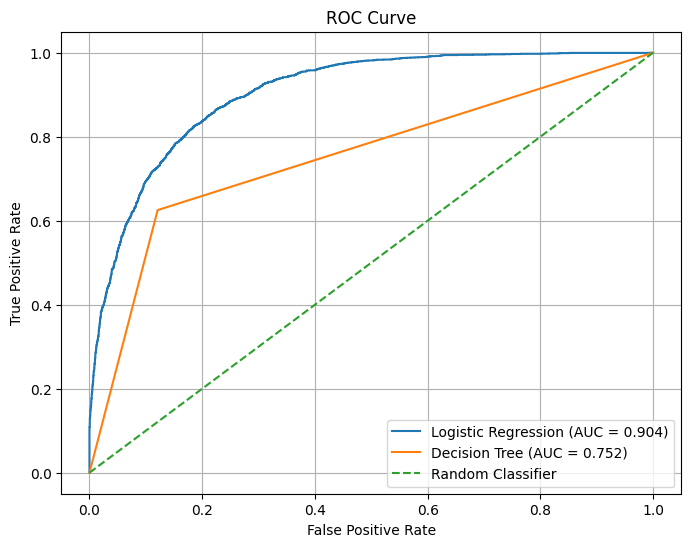

In [32]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve values
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

# Calculate AUC
roc_auc_logistic = auc(fpr_logistic, tpr_logistic)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {roc_auc_logistic:.3f})'
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f'Decision Tree (AUC = {roc_auc_tree:.3f})'
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

### Precision-Recall Curves

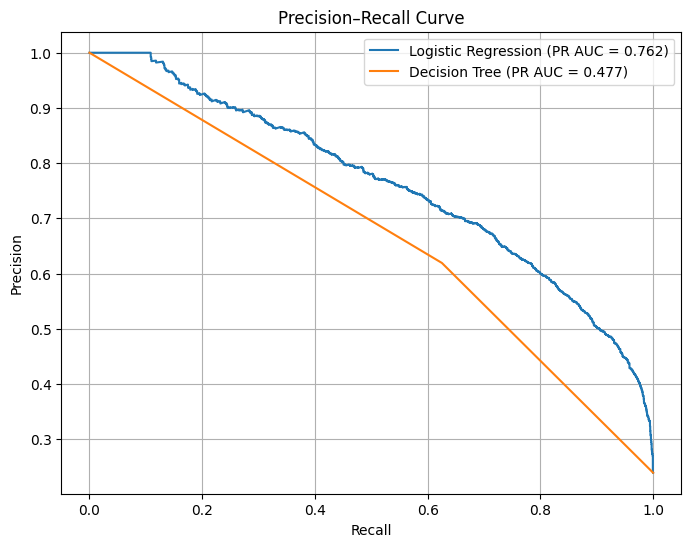

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# Calculate Precision-Recall curve values
precision_logistic, recall_logistic, _ = precision_recall_curve(
    y_test,
    y_prob_logistic
)

precision_tree, recall_tree, _ = precision_recall_curve(
    y_test,
    y_prob_tree
)

# Calculate PR AUC
pr_auc_logistic = average_precision_score(y_test, y_prob_logistic)
pr_auc_tree = average_precision_score(y_test, y_prob_tree)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall_logistic,
    precision_logistic,
    label=f'Logistic Regression (PR AUC = {pr_auc_logistic:.3f})'
)

plt.plot(
    recall_tree,
    precision_tree,
    label=f'Decision Tree (PR AUC = {pr_auc_tree:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

### Confusion Metrics

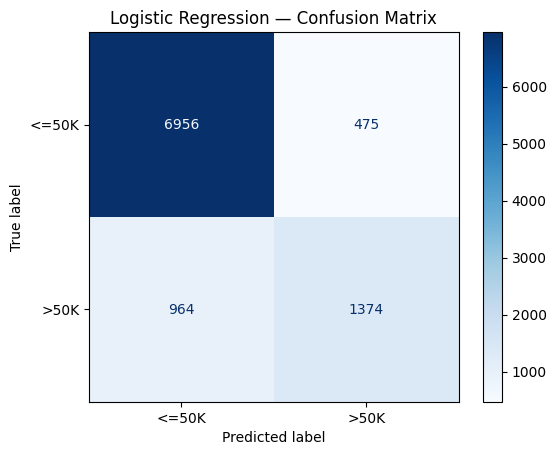

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=['<=50K', '>50K'],
    cmap='Blues'
)

plt.title('Logistic Regression — Confusion Matrix')
plt.show()



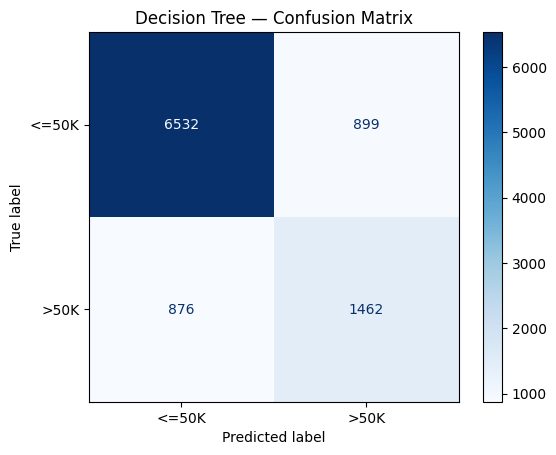

In [35]:
# Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    display_labels=['<=50K', '>50K'],
    cmap='Blues'
)

plt.title('Decision Tree — Confusion Matrix')
plt.show()

False negatives are more common than false positives for Logistic Regression (964 FN vs. 475 FP), indicating that the model misses a substantial number of individuals whose income is actually above $50K. For the Decision Tree, false positives and false negatives are nearly balanced (899 FP vs. 876 FN). Since both types of errors are relevant, the F1-score is an appropriate primary metric because it balances precision and recall. Recall should also be monitored because reducing false negatives is important when correctly identifying high-income individuals is the objective.

#**TASK 4**

### logistic Regression

In [41]:
import pandas as pd

# Get feature names after preprocessing
feature_names = logistic_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_pipeline.named_steps['classifier'].coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Top 10 positive coefficients
top_positive = coef_df.sort_values(
    by='Coefficient', ascending=False
).head(10)

# Top 10 negative coefficients
top_negative = coef_df.sort_values(
    by='Coefficient', ascending=True
).head(10)

print("Top 10 Positive Coefficients:")
print(top_positive.to_string(index=False))

print("\nTop 10 Negative Coefficients:")
print(top_negative.to_string(index=False))

Top 10 Positive Coefficients:
                               Feature  Coefficient
                     num__capital-gain     2.222389
cat__marital-status_Married-civ-spouse     1.586218
 cat__marital-status_Married-AF-spouse     1.224588
           cat__native-country_Ireland     1.074764
            cat__native-country_France     0.829413
       cat__occupation_Exec-managerial     0.788378
           cat__native-country_England     0.764711
                cat__relationship_Wife     0.761904
                    num__education-num     0.756377
          cat__native-country_Cambodia     0.706255

Top 10 Negative Coefficients:
                            Feature  Coefficient
    cat__occupation_Priv-house-serv    -1.411199
  cat__marital-status_Never-married    -1.230396
       cat__native-country_Columbia    -1.121187
                    cat__sex_Female    -1.004580
   cat__relationship_Other-relative    -0.949881
cat__native-country_Trinadad&Tobago    -0.941647
    cat__occupation_Farm

###Decision Tree

In [43]:
# Get the actual Decision Tree model
tree_model = tree_pipeline.named_steps['classifier']

# 1. Report tree depth
print("Decision Tree Depth:", tree_model.get_depth())

# 2. Train vs Test accuracy
train_score = tree_pipeline.score(X_train, y_train)
test_score = tree_pipeline.score(X_test, y_test)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)
print("Train-Test Gap:", train_score - test_score)

Decision Tree Depth: 56
Training Accuracy: 0.9999414999415
Testing Accuracy: 0.8183027945542021
Train-Test Gap: 0.18163870538729787


In [44]:
feature_names = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [45]:
from sklearn.tree import export_text

tree_rules = export_text(
    tree_model,
    feature_names=list(feature_names),
    max_depth=2
)

print(tree_rules)

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.83
|   |   |--- num__education-num <= 0.94
|   |   |   |--- truncated branch of depth 23
|   |   |--- num__education-num >  0.94
|   |   |   |--- truncated branch of depth 28
|   |--- num__capital-gain >  0.83
|   |   |--- num__age <= -1.33
|   |   |   |--- truncated branch of depth 2
|   |   |--- num__age >  -1.33
|   |   |   |--- truncated branch of depth 5
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.55
|   |   |--- num__capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 54
|   |   |--- num__capital-gain >  0.56
|   |   |   |--- truncated branch of depth 11
|   |--- num__education-num >  0.55
|   |   |--- num__capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 36
|   |   |--- num__capital-gain >  0.56
|   |   |   |--- truncated branch of depth 6



The Decision Tree's logic mostly makes sense. It first uses marital status, then capital gain and education, and sometimes age to predict whether a person earns more than $50K. These are reasonable factors because they can be related to income.

However, the tree is overfitting. Its training accuracy is almost 100%, but its test accuracy is only 81.83%. The tree is also very deep (56 levels), meaning it has become too complicated and is learning the training data too closely.

#**TASK 5**

Both Logistic Regression and Decision Tree are useful for further development, but they have different strengths. Logistic Regression is useful because its coefficients are easy to interpret and show how different features are associated with predicting income above $50K. The Decision Tree can capture more complex and nonlinear relationships. It achieved a test accuracy of 81.83%, with a precision of 61.92%, recall of 62.53%, F1-score of 62.23%, ROC-AUC of 75.22%, and PR-AUC of 47.69%.

However, the Decision Tree currently shows strong overfitting. Its training accuracy is almost 100%, while its test accuracy is only 81.83%, giving a train-test gap of about 18.16 percentage points. Therefore, I will keep Logistic Regression as an interpretable baseline and further tune the Decision Tree to reduce overfitting. Tomorrow, I plan to test preprocessing and model changes such as limiting the tree's maximum depth, increasing the minimum samples required for splits or leaves, and possibly adjusting class handling. The preprocessing pipeline will be saved and reused so that the same transformations are consistently applied to future data.